In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle
import statsmodels.api as sm


C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return ds.isel(j=y_idx, i=x_idx)

In [3]:
MLD = xr.open_dataset('MLD_ts_0.25.nc')['somxl010']
MLD['time_counter'] = MLD['time_counter'].dt.year

In [5]:
MLD

<xarray.DataArray 'somxl010' (time_counter: 35, j: 482, i: 341)> Size: 23MB
[5752670 values with dtype=float32]
Coordinates:
  * time_counter   (time_counter) int64 280B 1990 1991 1992 ... 2022 2023 2024
    time_centered  (time_counter) datetime64[ns] 280B ...
  * j              (j) int64 4kB 685 686 687 688 689 ... 1163 1164 1165 1166
  * i              (i) int64 3kB 809 810 811 812 813 ... 1146 1147 1148 1149
    gphit          (j, i) float64 1MB ...
    glamt          (j, i) float64 1MB ...
Attributes:
    standard_name:       ocean_mixed_layer_thickness_defined_by_sigma_theta
    long_name:           Mixed Layer Depth (dsigma = 0.01 wrt 10m)
    units:               m
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 yr
    cell_methods:        time: mean (interval: 1800 s)

In [9]:
## Annual Means 

ny, nx = MLD.sizes['j'], MLD.sizes['i']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for j_idx in range (ny):
    for i_idx in range (nx):
        point = MLD.isel(j=j_idx, i=i_idx)
        if np.isnan(point).all():
            continue
        results = sm.OLS(point.values, sm.add_constant(point['time_counter'])).fit() 
        trend_data[j_idx, i_idx] = results.params[1] 
        pval_data[j_idx, i_idx] = results.pvalues[1]
    print(j_idx)

trend_da = xr.DataArray(data = trend_data, dims=["j", "i"], 
        coords={ "j": MLD['j'],
        "i": MLD['i'],
        "gphit": (("j", "i"), MLD['gphit'].values),
        "glamt": (("j", "i"), MLD['glamt'].values)}, name="trend",
        attrs={"description": "MLD Linear Trend"})

pval_da = xr.DataArray(data = pval_data, dims=["j", "i"], 
        coords={ "j": MLD['j'],
        "i": MLD['i'],
        "gphit": (("j", "i"), MLD['gphit'].values),
        "glamt": (("j", "i"), MLD['glamt'].values)}, name="trend",
        attrs={"description": "MLD Linear Trend p-value"})

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

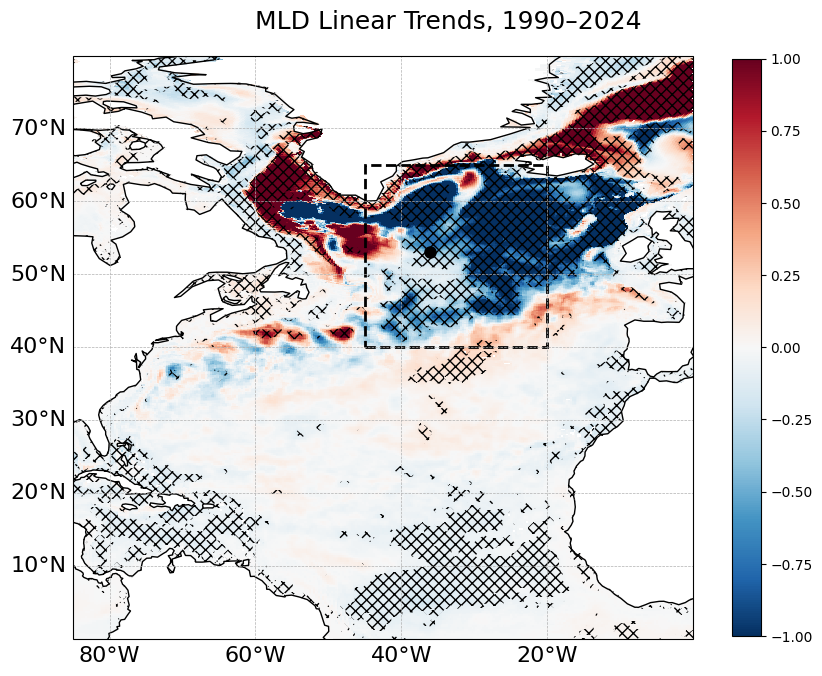

In [13]:
## Hatched Plot 

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['glamt'], trend_da['gphit'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('MLD Linear Trends, 1990–2024',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)
plt.savefig('MLD_trends.png')


In [8]:
## September MLD 

catalog = OceanDataCatalog(catalog_name='noc-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1_monthly = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_monthly = {'parent': {'domain': config, 'gridT': ds1_monthly}}
dt_global_monthly = NEMODataTree.from_datasets(datasets = datasets_monthly)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_monthly = dt_global_monthly.clip_grid(grid='gridT', bbox=bbox)

# Convert to datasets
ds_monthly = (dt_monthly['gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y
              Title: T1y Icechunk repository
              Description: **Annual mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m
              Title: T1m Icechunk repository
              Description: **Monthly mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1y_3d
       

In [24]:
ds_septembers = ds_monthly.where(ds_monthly['time_counter'].dt.month == 9, drop = True)
ds_septembers['time_counter'] = ds_septembers['time_counter'].dt.year

In [10]:
MLD_sept = ds_septembers['somxl010'].compute()

In [25]:
MLD_sept

<xarray.DataArray 'somxl010' (time_counter: 35, j: 482, i: 341)> Size: 23MB
array([[[      nan, 23.713625, 23.737444, ..., 23.09421 , 23.053768,
         23.549732],
        [      nan, 24.1771  , 24.780401, ..., 24.620714, 24.401312,
         24.871973],
        [      nan, 25.67685 , 25.31731 , ..., 26.049614, 26.612417,
         27.006514],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan, 19.396801, 19.65298 , ..., 19.403437, 19.596262,
         19.818865],
        [      nan, 21.032143, 22.011484, ..., 21.741179, 21.770748,
         22.11086 ],
        [      nan, 22.311895, 22.735987, ..., 23.500824, 23.350151,
         23.011377],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan, 18.73257 , 19.240383, ..., 25.238409, 25.072271,
         25.687288],
        [      nan, 20.386583, 20.422777, ..., 26.317938, 26.51009 ,
         26.794884],
        [      nan, 21.402191, 21.532585, ..., 28.211199, 27.754044,
         27.834867],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], shape=(35, 482, 341), dtype=float32)
Coordinates:
  * time_counter   (time_counter) int64 280B 1990 1991 1992 ... 2022 2023 2024
    time_centered  (time_counter) datetime64[ns] 280B 1990-09-16 ... 2024-09-16
  * j              (j) int64 4kB 685 686 687 688 689 ... 1163 1164 1165 1166
  * i              (i) int64 3kB 809 810 811 812 813 ... 1146 1147 1148 1149
    gphit          (j, i) float64 1MB 0.0 0.0 0.0 0.0 ... 79.51 79.41 79.3 79.2
    glamt          (j, i) float64 1MB -85.0 -84.75 -84.5 ... 48.28 48.54 48.79
Attributes:
    standard_name:       ocean_mixed_layer_thickness_defined_by_sigma_theta
    long_name:           Mixed Layer Depth (dsigma = 0.01 wrt 10m)
    units:               m
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

In [26]:
ny, nx = MLD_sept.sizes['j'], MLD_sept.sizes['i']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for j_idx in range (ny):
    for i_idx in range (nx):
        point = MLD_sept.isel(j=j_idx, i=i_idx)
        if np.isnan(point).all():
            continue
        results = sm.OLS(point.values, sm.add_constant(point['time_counter'])).fit() 
        trend_data[j_idx, i_idx] = results.params[1] 
        pval_data[j_idx, i_idx] = results.pvalues[1]
    print(j_idx)

trend_da1 = xr.DataArray(data = trend_data, dims=["j", "i"], 
        coords={ "j": MLD_sept['j'],
        "i": MLD_sept['i'],
        "gphit": (("j", "i"), MLD_sept['gphit'].values),
        "glamt": (("j", "i"), MLD_sept['glamt'].values)}, name="trend",
        attrs={"description": "September MLD Linear Trend"})

pval_da1 = xr.DataArray(data = pval_data, dims=["j", "i"], 
        coords={ "j": MLD_sept['j'],
        "i": MLD_sept['i'],
        "gphit": (("j", "i"), MLD_sept['gphit'].values),
        "glamt": (("j", "i"), MLD_sept['glamt'].values)}, name="trend",
        attrs={"description": "September MLD Linear Trend p-value"})

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [28]:
select_by_latlon(trend_da1, 55, -30.0)


x index = 221
y index = 258


<xarray.DataArray 'trend' ()> Size: 4B
array(-0.06158272, dtype=float32)
Coordinates:
    j        int64 8B 943
    i        int64 8B 1030
    gphit    float64 8B 54.94
    glamt    float64 8B -29.94
Attributes:
    description:  September MLD Linear Trend

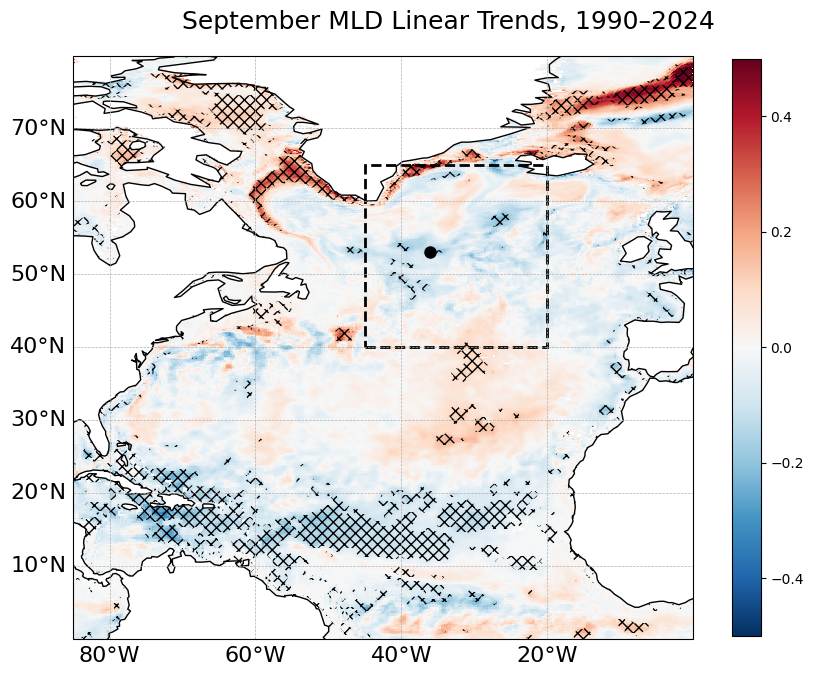

In [12]:
sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['glamt'], trend_da['gphit'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -0.5, vmax = 0.5)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('September MLD Linear Trends, 1990–2024',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)
plt.savefig('SEP_MLD_trends.png')


In [18]:
## February MLD

ds_febs = ds_monthly.where(ds_monthly['time_counter'].dt.month == 2, drop = True)
ds_febs['time_counter'] = ds_febs['time_counter'].dt.year
MLD_feb = ds_febs['somxl010'].compute()

In [19]:
ny, nx = MLD_feb.sizes['j'], MLD_feb.sizes['i']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for j_idx in range (ny):
    for i_idx in range (nx):
        point = MLD_feb.isel(j=j_idx, i=i_idx)
        if np.isnan(point).all():
            continue
        results = sm.OLS(point.values, sm.add_constant(point['time_counter'])).fit() 
        trend_data[j_idx, i_idx] = results.params[1] 
        pval_data[j_idx, i_idx] = results.pvalues[1]
    print(j_idx)

trend_da = xr.DataArray(data = trend_data, dims=["j", "i"], 
        coords={ "j": MLD_feb['j'],
        "i": MLD_feb['i'],
        "gphit": (("j", "i"), MLD_feb['gphit'].values),
        "glamt": (("j", "i"), MLD_feb['glamt'].values)}, name="trend",
        attrs={"description": "Febraury MLD Linear Trend"})

pval_da = xr.DataArray(data = pval_data, dims=["j", "i"], 
        coords={ "j": MLD_feb['j'],
        "i": MLD_feb['i'],
        "gphit": (("j", "i"), MLD_feb['gphit'].values),
        "glamt": (("j", "i"), MLD_feb['glamt'].values)}, name="trend",
        attrs={"description": "February MLD Linear Trend p-value"})

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [23]:
select_by_latlon(trend_da, 55, -30.0)


x index = 221
y index = 258


<xarray.DataArray 'trend' ()> Size: 4B
array(-2.572663, dtype=float32)
Coordinates:
    j        int64 8B 943
    i        int64 8B 1030
    gphit    float64 8B 54.94
    glamt    float64 8B -29.94
Attributes:
    description:  Febraury MLD Linear Trend

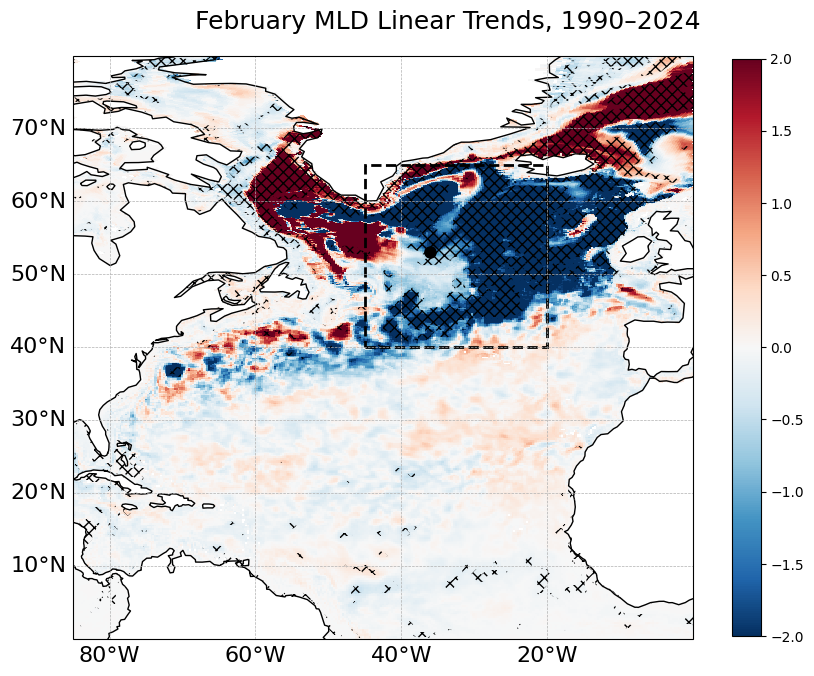

In [16]:
sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['glamt'], trend_da['gphit'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -3, vmax = 3)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('February MLD Linear Trends, 1990–2024',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)
plt.savefig('FEB_MLD_trends.png')
